In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

In [2]:
from scipy.stats import kurtosis
from scipy.signal import stft

In [3]:
n1=pd.read_csv("data/Harmonic_n1_W1R_A001_VEL020_fs1000.csv")
n2=pd.read_csv("data/Harmonic_n2_W1R_A001_VEL020_fs1000.csv")
n3=pd.read_csv("data/Harmonic_n3_W1R_A001_VEL020_fs1000.csv")

wf_30_var2060=pd.read_csv("data/WF_L030_W1R_TI_High_VEL020_060_fs1000.csv")
wf_60_cte20=pd.read_csv("data/WF_L060_W1R_TI_High_VEL020_fs1000.csv")
wf_30_cte20=pd.read_csv("data/L030_TI_High_VEL020_fs1000.csv")

wf_30_var2060_27000 = wf_30_var2060.tail(27001)
wf_30_var2060_27000.reset_index(drop=True, inplace=True)

Sx=(wf_30_cte20,wf_60_cte20,wf_30_var2060_27000,n1,n2,n3)

In [4]:
speed_profile=pd.read_csv("data/Perfil_VEL_020_060.csv")

speed_profile_cut = speed_profile.tail(27001)
speed_profile_cut.reset_index(drop=True, inplace=True)

t2 = speed_profile_cut['time [s]'].to_numpy()
fr_m_s=speed_profile_cut['vel [m/s]'].to_numpy()

#speed_profile_cut.head()

In [6]:
fs=1e3
#N=len(t[0])
N=len(Sx[0]['t [s]'].to_numpy())
n=np.arange(N)
N_Sx=len(Sx)
t=[]
Sx_no_defect=[]
Sx_defect=[]
f_fail=[]

for index in range(N_Sx):
    t.append(Sx[index]['t [s]'].to_numpy())
    az_no_flat = Sx[index]['az NO FLAT [m/s2]'].to_numpy()
    az_with_flat = Sx[index]['az WITH FLAT [m/s2]'].to_numpy()

    az_no_flat = az_no_flat - np.mean(az_no_flat)
    az_with_flat = az_with_flat - np.mean(az_with_flat)

    #Sx_no_flat.append(np.abs(signal.hilbert(az_no_flat)))
    #Sx_flat.append(np.abs(signal.hilbert(az_with_flat)))

    Sx_no_defect.append(az_no_flat)
    Sx_defect.append(az_with_flat)

    if index != 2:
        v=20e3/3600
        r=0.46
        fr=v/(2*np.pi*r)
        f_fail.append(fr*np.ones((N,1)))
    else:
        f_fail.append(fr_m_s/(2*np.pi*r))

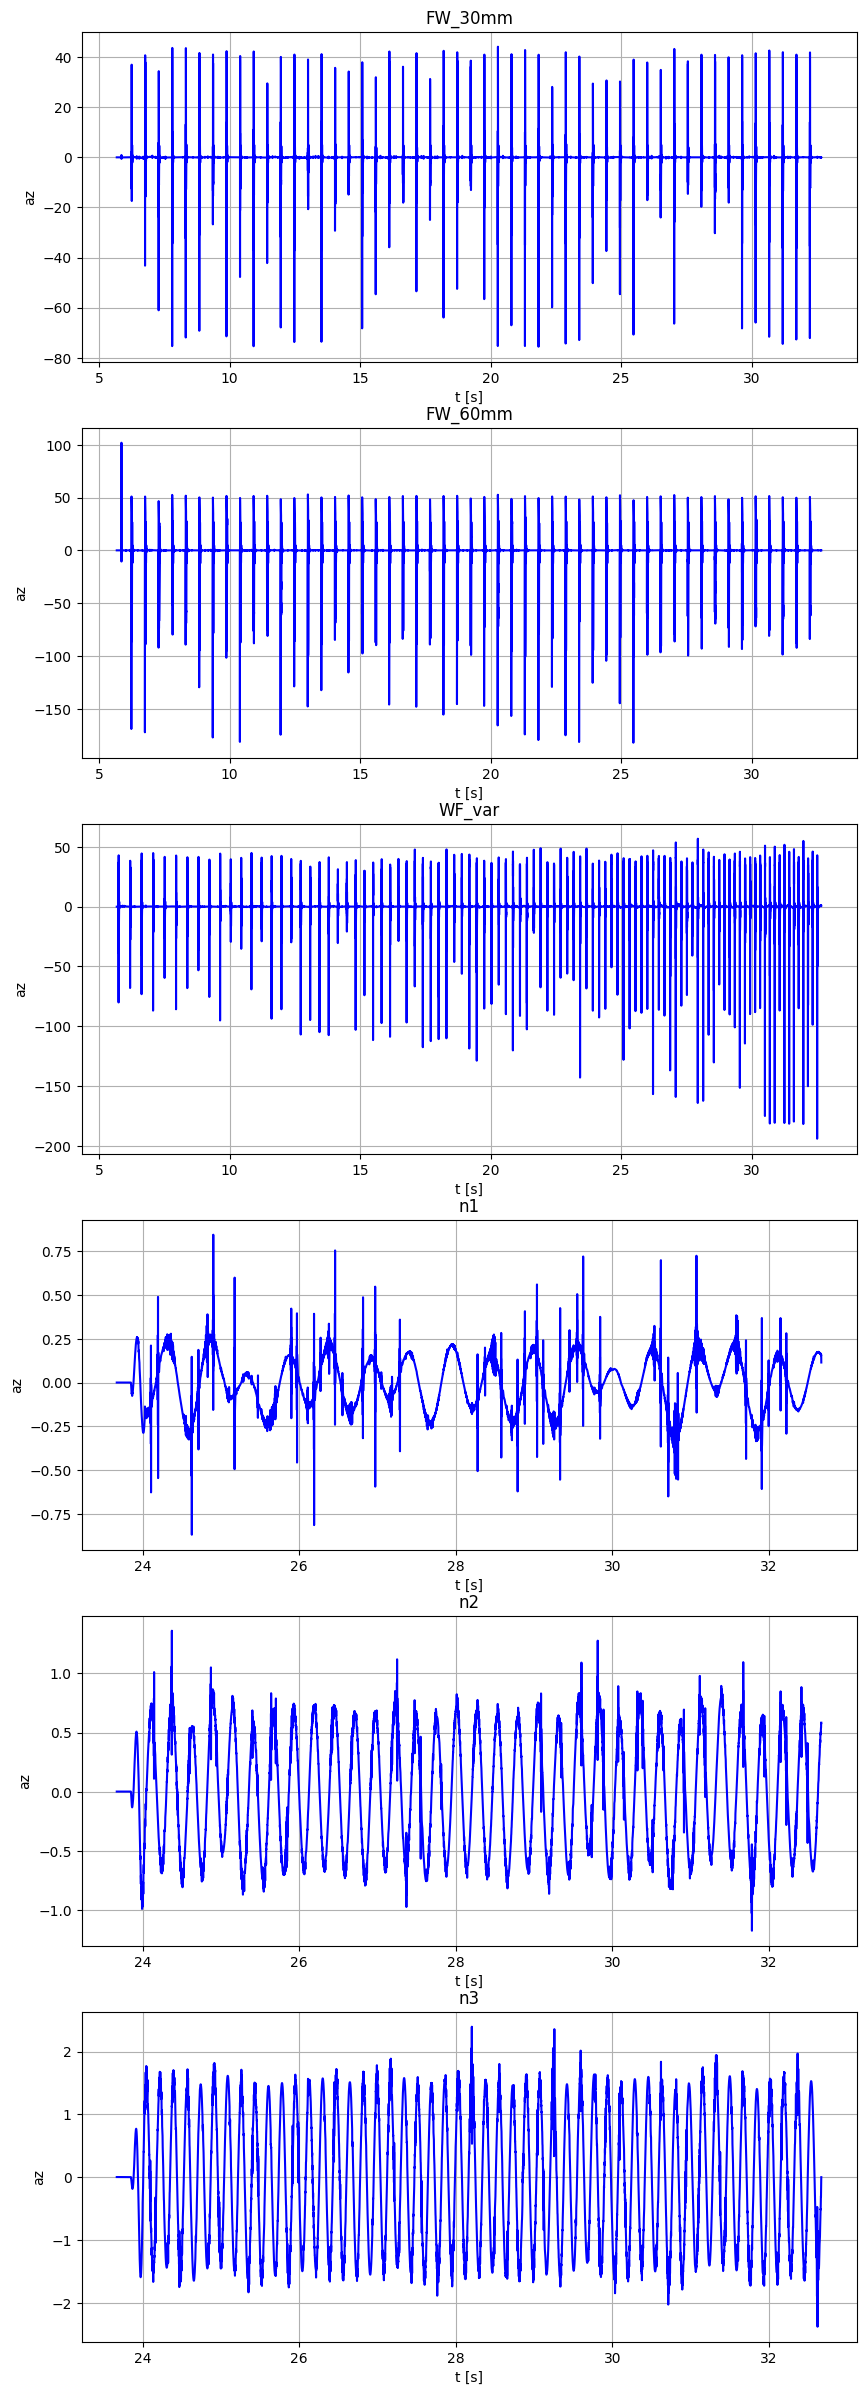

In [7]:
fig, axs = plt.subplots(N_Sx, 1, figsize=(10, 30))

labels=['FW_30mm',
         'FW_60mm',
         'WF_var',
         'n1',
         'n2',
         'n3']

for i in range(N_Sx):
    axs[i].plot(t[i],Sx_defect[i], label=labels[i], color='b')
    axs[i].set_title(labels[i])
    axs[i].set_xlabel('t [s]')
    axs[i].set_ylabel('az')
    axs[i].grid(True)
    #axs[i].legend()

In [8]:
for i in range(N_Sx):
    print(i, kurtosis(Sx_defect[i], fisher=False))

0 131.87681864596547
1 53.843569809877074
2 152.7984022307446
3 3.2775518994017574
4 1.6512377986293485
5 1.582712142167385


---

In [37]:
Sx_index=4
f_stft,t_stft,Zxx = stft(Sx_defect[Sx_index],fs=fs, nperseg=256, noverlap=128)
t_stft+=t[Sx_index][0]

mag = np.abs(Zxx)
SK_f_t = np.zeros_like(mag)

for f_i in range(len(f_stft)):
    for t_i in range(len(t_stft)):
        win_len=20
        i_start=max(0, t_i - win_len // 2)
        i_end=min(len(t_stft), t_i + win_len // 2)
        slice_time = mag[f_i, i_start:i_end]

        if len(slice_time) > 3:
            SK_f_t[f_i, t_i] = kurtosis(slice_time, fisher=False)
        else:
            SK_f_t[f_i, t_i] = np.nan

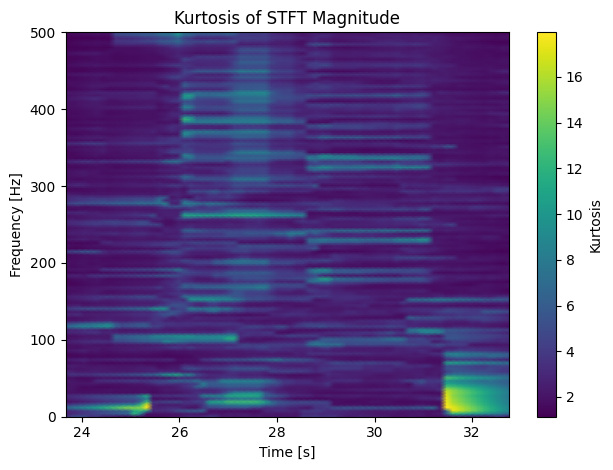

In [38]:
plt.pcolormesh(t_stft, f_stft, SK_f_t, shading='gouraud')
plt.colorbar(label='Kurtosis')
plt.ylabel('Frequency [Hz]')
plt.xlabel('Time [s]')
plt.title('Kurtosis of STFT Magnitude')
plt.tight_layout()
plt.show()

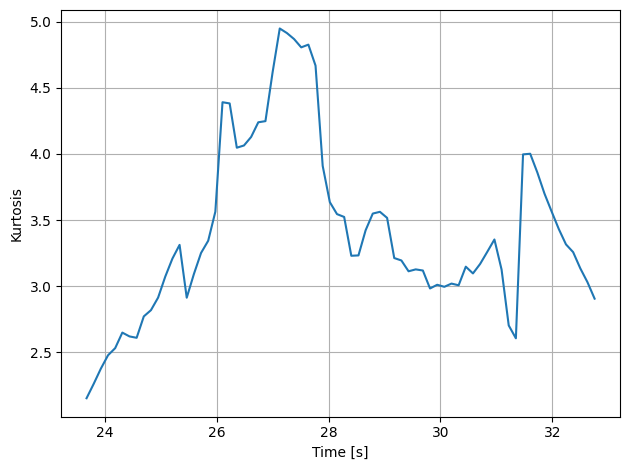

In [39]:
SK_t=np.nanmean(SK_f_t, axis=0)
plt.plot(t_stft, SK_t)
plt.xlabel('Time [s]')
plt.ylabel('Kurtosis')
#plt.title('Mean Kurtosis Over Frequency')
plt.grid(True)
plt.tight_layout()
plt.show()

---

In [5]:
fs=1e3
r=0.46
t = np.linspace(0, 5, int(5 * fs), endpoint=False)
N=len(t)

In [6]:
Ar= 1   #Amplitude
f = 55    #Resonant Frequency in Hz
b=50      #Exponential decay factor

n=np.arange(N)

#fr_var=curve_rayleigh(t)
#v_var=1e3*np.linspace(20,40,N) # km/h
v_var=20e3*np.ones((N,))

fr_var=v_var/(3600*2*np.pi*r)
print(np.min(fr_var))

f_fail=fr_var.copy()
ω_fail=2*np.pi*f_fail
θr_fail=np.cumsum(ω_fail)/fs

t_indexes=[]
t_impact=[]
N_of_impacts=np.int32(np.floor(np.max(θr_fail)/(2*np.pi)))+1
for i in range(N_of_impacts):
    t_index=np.argmin(np.abs(θr_fail-i*2*np.pi))
    t_indexes.append(t_index)
    t_impact.append(t[t_index])
    #print(i,t_index,t[t_index])

impacts=(np.array(t_indexes),np.array(t_impact))

1.922161148452842


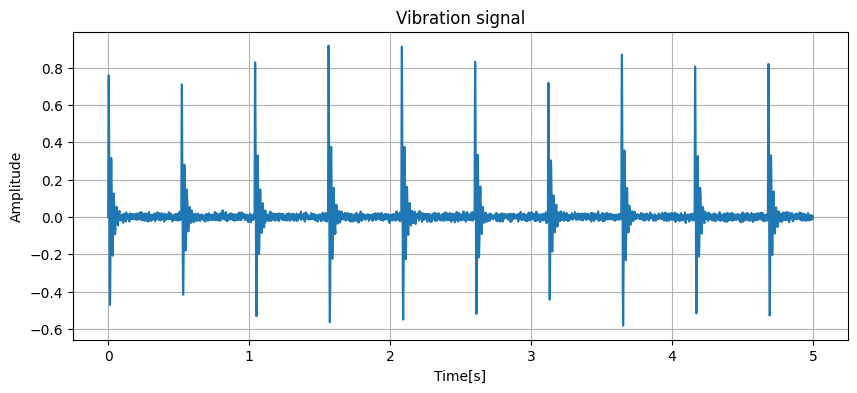

In [7]:
def conditional_exp(t, b):
    result = np.zeros_like(t, dtype=float)
    positive_indices = t > 0
    result[positive_indices] = np.exp(-b * t[positive_indices])
    return result

Sx_var=np.zeros((N,))
#random_phase = np.random.choice([0, np.pi], size=N)
random_amplitudes = np.random.normal(loc=Ar, scale=0.1*Ar, size=N)

for t_i in range(len(t_impact)):
    time_diff=t[0]+n/fs-t_impact[t_i]
    Sx_var+=random_amplitudes[t_i]*np.sin(2*np.pi*f*(time_diff))*conditional_exp(time_diff, b)*np.heaviside(time_diff, 1)

#desired_noise_power = 1e-1
desired_noise_power = 1e-4
#Sx_var=Sx_var-np.mean(Sx_var)

Sx_var=Sx_var + np.random.normal(loc=0.0, scale=np.sqrt(desired_noise_power), size=Sx_var.shape)
#Sx_var = np.random.normal(loc=0.0, scale=np.sqrt(desired_noise_power), size=Sx_var.shape) # no fail

plt.figure(figsize=(10, 4))
plt.plot(t,Sx_var)
plt.grid(True)
plt.title('Vibration signal')
plt.xlabel('Time[s]')
plt.ylabel('Amplitude')
plt.show()

In [44]:
f_stft,t_stft,Zxx = stft(Sx_var,fs=fs, nperseg=128, noverlap=64)
mag = np.abs(Zxx)

SK_f_t = np.zeros_like(mag)

for f_i in range(len(f_stft)):
    for t_i in range(len(t_stft)):
        win_len=10
        i_start=max(0, t_i - win_len // 2)
        i_end=min(len(t_stft), t_i + win_len // 2)
        slice_time = mag[f_i, i_start:i_end]

        if len(slice_time) > 3:
            SK_f_t[f_i, t_i] = kurtosis(slice_time, fisher=False)
        else:
            SK_f_t[f_i, t_i] = np.nan

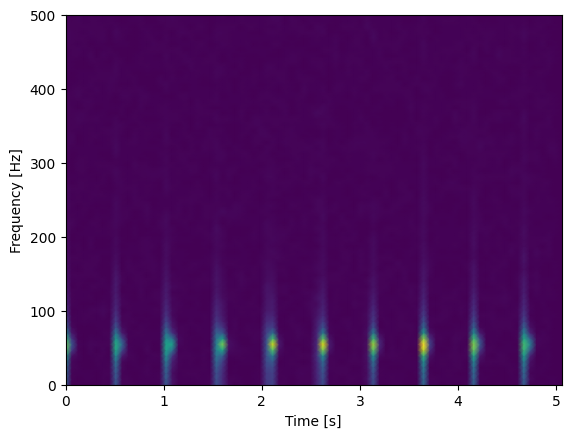

In [45]:
plt.pcolormesh(t_stft, f_stft, mag, shading='gouraud')
#plt.colorbar(label='Kurtosis')
plt.ylabel('Frequency [Hz]')
plt.xlabel('Time [s]')
#plt.title('Kurtosis of STFT Magnitude')
#plt.tight_layout()
plt.show()

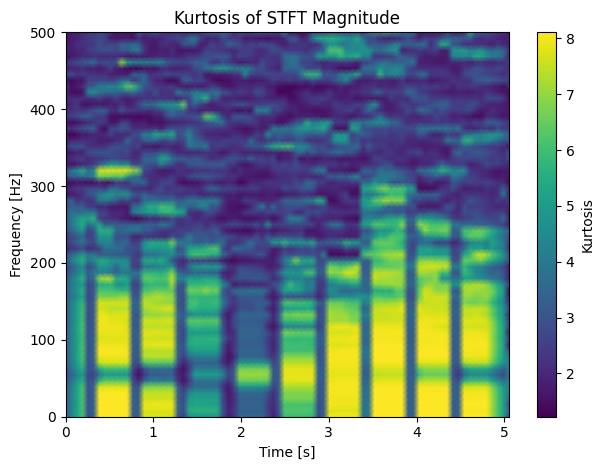

In [46]:
plt.pcolormesh(t_stft, f_stft, SK_f_t, shading='gouraud')
plt.colorbar(label='Kurtosis')
plt.ylabel('Frequency [Hz]')
plt.xlabel('Time [s]')
plt.title('Kurtosis of STFT Magnitude')
plt.tight_layout()
plt.show()

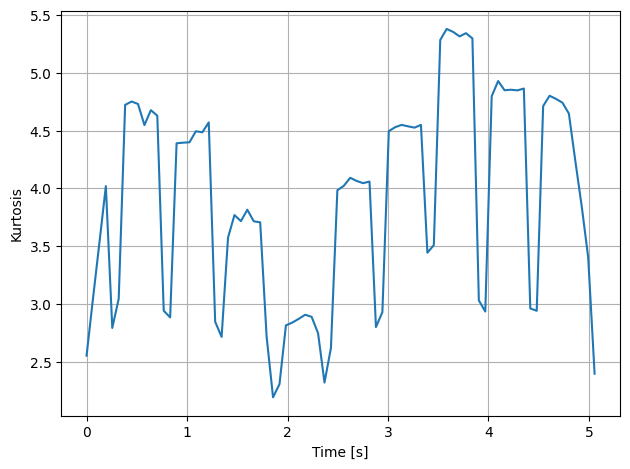

In [47]:
SK_t=np.nanmean(SK_f_t, axis=0)
plt.plot(t_stft, SK_t)
plt.xlabel('Time [s]')
plt.ylabel('Kurtosis')
#plt.title('Mean Kurtosis Over Frequency')
plt.grid(True)
plt.tight_layout()
plt.show()

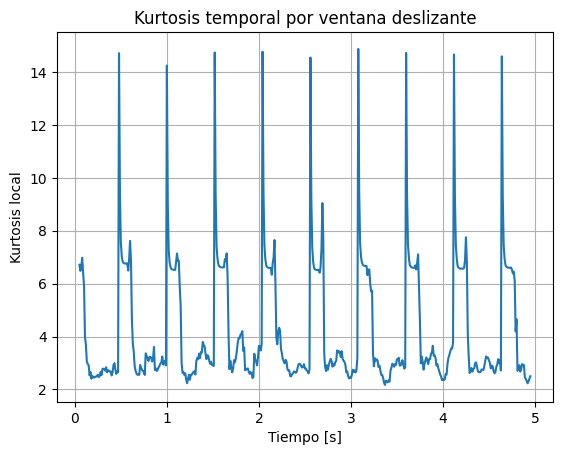

In [59]:
window_size = int(0.1 * fs)  # 100 ms de ventana
step_size = int(0.01 * fs)   # 10 ms entre pasos

# Cálculo de la kurtosis en ventanas móviles
kurtosis_vals = []
time_vals = []

for i in range(0, len(Sx_var) - window_size + 1, step_size):
    window = Sx_var[i:i + window_size]
    k = kurtosis(window, fisher=False)
    kurtosis_vals.append(k)
    time_vals.append(t[i + window_size // 2])  # tiempo centrado

# Visualización
plt.plot(time_vals, kurtosis_vals)
plt.xlabel("Tiempo [s]")
plt.ylabel("Kurtosis local")
plt.title("Kurtosis temporal por ventana deslizante")
plt.grid(True)
plt.show()